# Contract Analysis Notebook

This README provides instructions on how to set up and run the contract analysis notebook.

## Setup
Before running the notebook, ensure you have all the necessary dependencies installed.

## API Keys
This notebook requires API keys for OpenAI and DeepSeek. Remember to replace `"your OpenAIKEY"` and `"your DeepSeekKEY"` in the notebook with your actual API keys.

## Usage
Follow these steps to execute the contract analysis workflow.

### 1. Build JSON Dataset
First, you'll need to create the initial JSON dataset from your contract examples:


In [1]:
from JsonBuilder import json_builder, copy_labels
from APIcall import contract_analysis, run_discrepancy_check
from metrics import compute_metrics_from_json ,analyze_benchmarks_from_json, analyze_stability

```python
from JsonBuilder import json_builder
json_builder("../dataset/contractExamples_org", "contracts.json")
```

This command processes the contract examples in `../dataset/contractExamples_org` and generates a `contracts.json` file.

### 2. Perform Contract Analysis
Next, run the contract analysis using the specified models:

```python
from APIcall import contract_analysis
contract_analysis("contracts.json", "contracts.json", "your OpenAIKEY", "your DeepSeekKEY")
```

This step utilizes your OpenAI and DeepSeek API keys to analyze the contracts, enriching the `contracts.json` file with the analysis results.

In [ ]:
json_builder("../dataset/contractExamples_org","contracts.json")
contract_analysis("contracts.json", "contracts.json", "Your OpenAI key","Your DeepSeek Key")

Results saved to 'contracts.json'.
Contracts analyzed. Saved to 'contracts.json'.


### 3. Manual Labeling
After the automatic analysis, manual labeling of the `contracts.json` file is required. This crucial step involves human review and annotation of the contracts based on specific criteria.

To save time on repeated labeling, especially if you have previously labeled contracts, you can use the copy_labels function:

# Python

```python
def copy_labels(
    reference_json_path: str,
    target_json_path: str
) -> int:
    """
    Copies the 'label_expected' values from a reference JSON file and
    overwrites the target file with the updated content.

    **WARNING: This function is destructive and will overwrite the file
    specified in `target_json_path`.**

    Args:
        reference_json_path (str): Path to the JSON file containing the correct labels (the source).
        target_json_path (str): Path to the JSON file to be updated and overwritten.

    Returns:
        int: The number of sections successfully updated. Returns 0 if there is an error.
    """
```

This function allows you to copy `label_expected` values from a `reference_json_path` to your `target_json_path`, saving you from re-labeling contracts that are already annotated. **Be aware that this function is destructive and will overwrite the target file.**

### 4. (Optional) Check for Discrepancies
You can optionally check for discrepancies between the analyzed labels and a ground truth (manual) labeling:

```python
from APIcall import run_discrepancy_check
run_discrepancy_check("contracts.json", "contracts.json")
```

This will compare the automatically generated labels with your manual labels and report any mismatches.

In [3]:
copy_labels("summary.json", "contracts.json")


Starting to modify file: 'contracts.json'...
Loaded 173 labels from the reference file.

--- Process completed ---
Total sections reviewed: 189
'label_expected' values copied and updated: 189
File 'contracts.json' has been modified and saved.


189

In [ ]:
run_discrepancy_check("contracts.json","contractsReviewed.json")

### 5. Compute Metrics
Compute various metrics based on the analysis results:

```python
from metrics import compute_metrics_from_json
compute_metrics_from_json("contracts.json", ["gpt4", "DS", "GPT4o", "GPT35"], ["legality", "abusiveness", "risk_areas", "vagueness", "legal_gaps"])
```

This command calculates metrics for the specified models and categories from your `contracts.json` file.



📊 METRICS BY MODEL:

       Precision  Recall  F1-score    AUC
gpt4       0.514   0.765     0.615  0.750
DS         0.321   0.910     0.475  0.603
GPT4o      0.417   0.934     0.576  0.728
GPT35      0.445   0.735     0.555  0.700


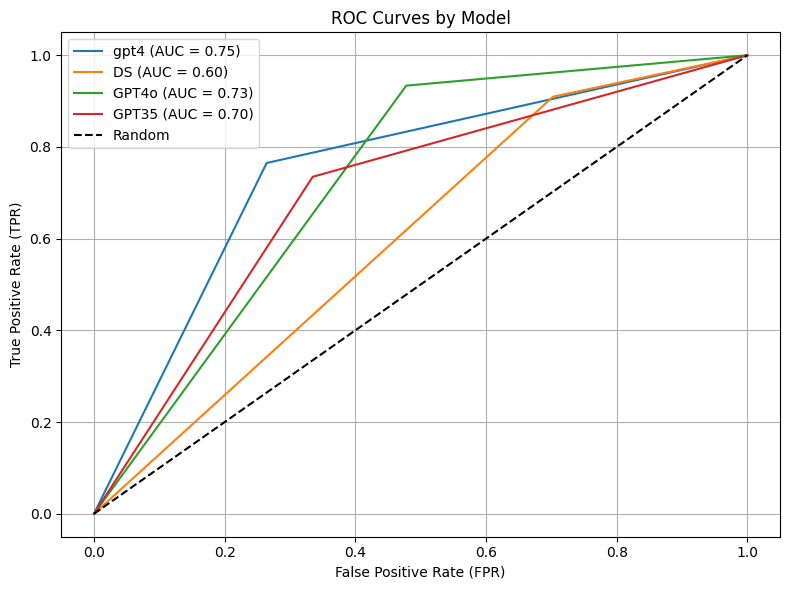

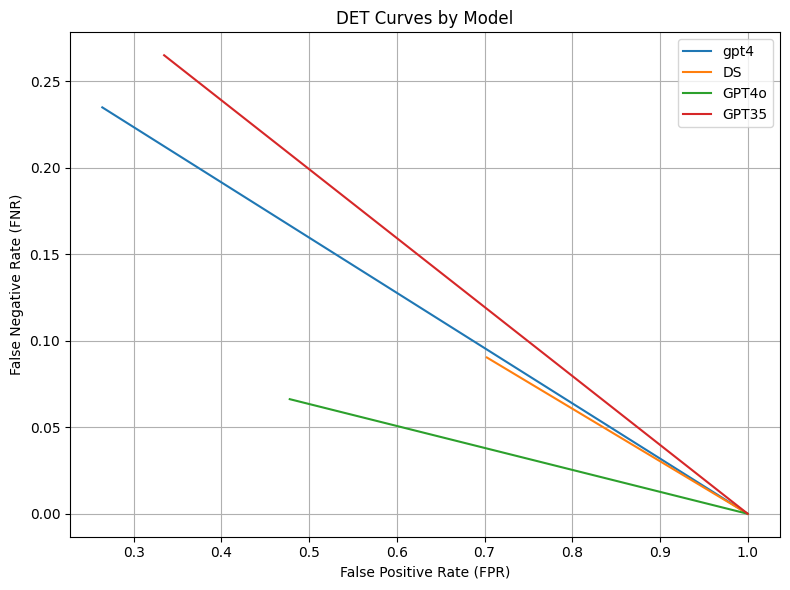

In [4]:
compute_metrics_from_json("contracts.json", ["gpt4", "DS", "GPT4o", "GPT35"], ["legality", "abusiveness", "risk_areas", "vagueness", "legal_gaps"])


### 6. Analyze Benchmarks
Analyze the performance benchmarks of the different models:

```python
from metrics import analyze_benchmarks_from_json
file_path = "contracts.json"
model_list = ["DS", "gpt4", "GPT4o", "GPT35"]
analyze_benchmarks_from_json(file_path, model_list)
```

This script will provide insights into how each model performed against the benchmarks.

### 7. Analyze Stability
To analyze stability, you must create several JSON files from previous runs and place them in a single directory (for example, `output_json`). Once that's done, you can compute the stability metrics:

```python
from metrics import analyze_stability
analyze_stability("output_json", ["DS", "gpt4", "GPT4o", "GPT35"])
```

This will assess the consistency and stability of the model's outputs across different runs.


Initializing models for benchmarks (this may take a while)...
Models ready.

Starting benchmark analysis by model...
Processing model: DS...
Processing model: gpt4...
Processing model: GPT4o...
Processing model: GPT35...

--- Text Quality Benchmark Results by Model ---
       Readability (Flesch)  Perplexity  Semantic Coherence
Model                                                      
DS                    30.97       71.04                0.10
gpt4                  36.68       46.06                0.12
GPT4o                 27.24       51.48                0.12
GPT35                 26.19       41.09                0.11


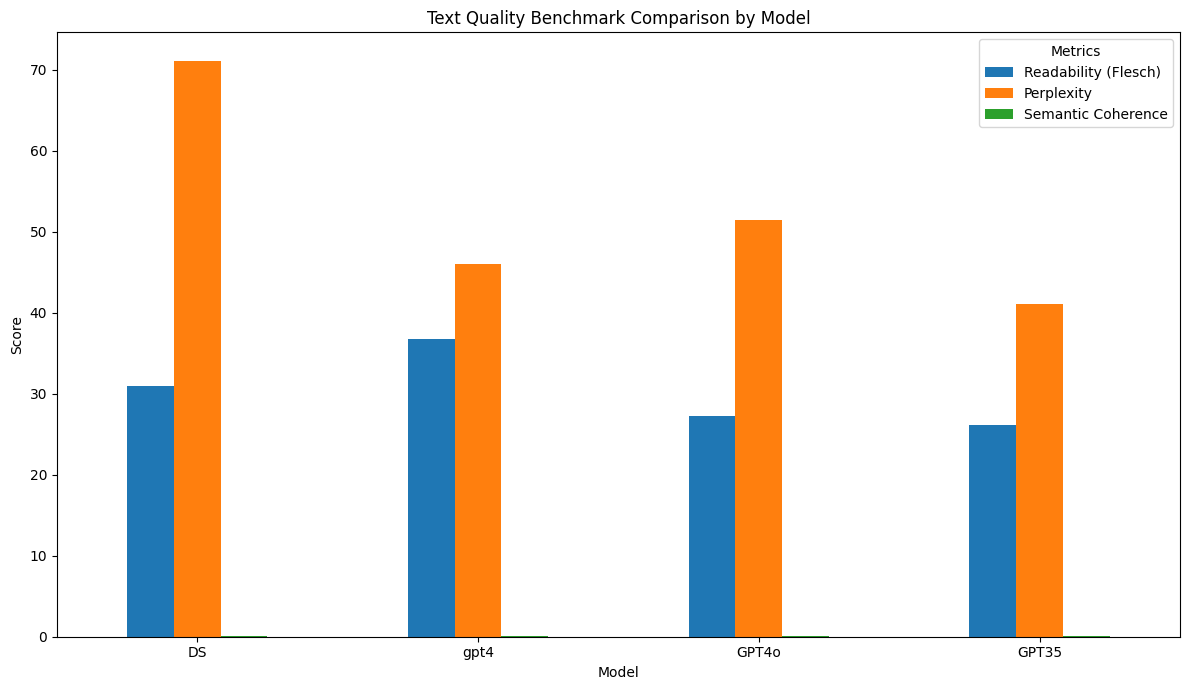

In [5]:
ruta_del_archivo = "contracts.json"
lista_modelos = ["DS", "gpt4", "GPT4o", "GPT35"]
analyze_benchmarks_from_json(ruta_del_archivo,lista_modelos)

Found 3 JSON files to analyze.

Calculating stability and consistency per model...

--- Stability and Self-Consistency Results ---
       Stability  Self-Consistency
Model                             
DS        0.1082            0.9961
gpt4      0.1977            0.8281
GPT4o     0.1844            0.8382
GPT35     0.2129            0.8324


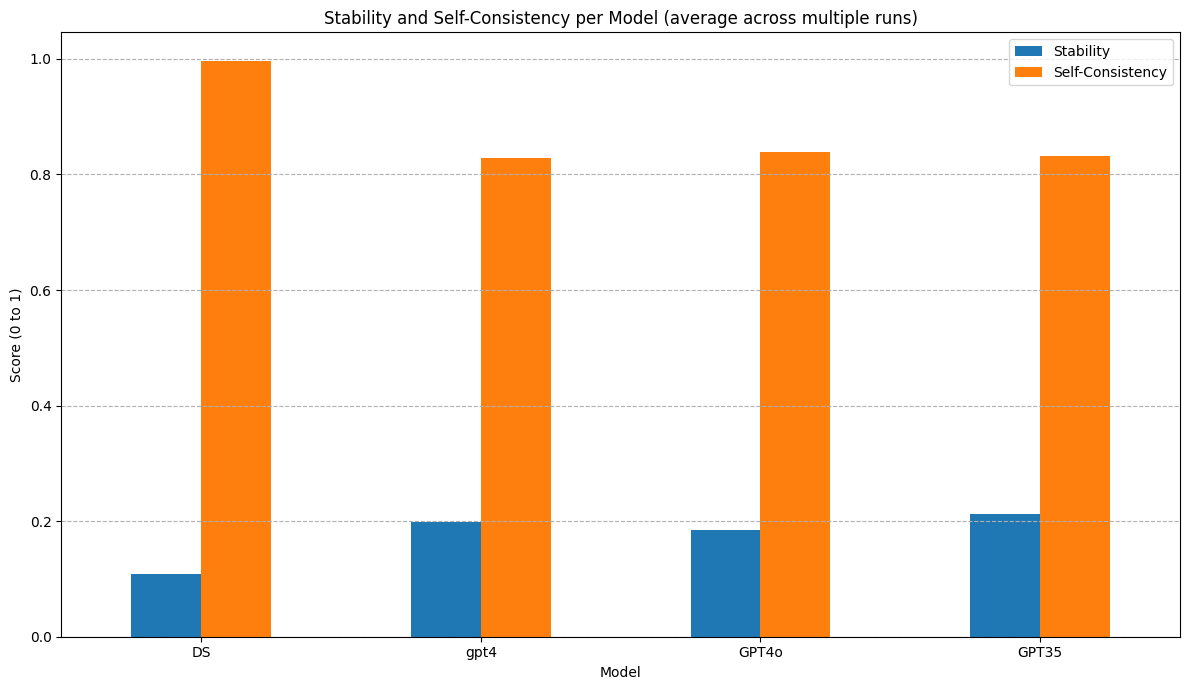

In [9]:
analyze_stability("output_json",["DS", "gpt4", "GPT4o", "GPT35"])